# Project Delay Prediction Model Summary

This notebook summarizes the project-delay modeling results in a customer-facing format. It focuses on what the model is trying to do, how well it performs under different validation tests, and what the results imply for practical use.

The underlying model work used project setup features and the approved keyword feature set. The random forest models include tuned regularization controls for tree depth, leaf size, split size, and feature sampling. This summary does not refit the models; it reads the validated regularized model result files produced by the modeling notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

HEADLINE_PATH = Path('project_delay_rf_approved_keywords_headline_comparison_2026-06-11.csv')
REG_PATH = Path('project_delay_rf_approved_keywords_regression_comparison_2026-06-11.csv')
BIN_PATH = Path('project_delay_rf_approved_keywords_binary_comparison_2026-06-11.csv')
THREE_PATH = Path('project_delay_rf_approved_keywords_three_bin_comparison_2026-06-11.csv')
DATA_PATH = Path('custpaydetails_project_feature_table_with_approved_keywords_2026-06-11.csv')
REG_PARAMS_PATH = Path('project_delay_rf_approved_keywords_regularization_params_2026-06-12.csv')

headline = pd.read_csv(HEADLINE_PATH)
regression = pd.read_csv(REG_PATH)
binary = pd.read_csv(BIN_PATH)
three_bin = pd.read_csv(THREE_PATH)
regularization_params = pd.read_csv(REG_PARAMS_PATH)

def display_percent_table(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: '' if pd.isna(x) else f'{x:.3f}')
    display(out)

feature_label = {'total_usable': 'All non-leakage features', 'before_only': 'Beginning-only features'}
headline['Feature Set'] = headline['FeatureSet'].map(feature_label)

## Executive Summary

The regularized random forest model is strongest at answering a practical binary question: **is this project likely to be delayed or not?**

The model remains less strong at precisely estimating the degree of delay, especially when forcing outcomes into three severity bins. That pattern is common in this type of operational data: project setup features can often flag risk, but exact severity depends on later execution conditions that are not fully known at the beginning.

In [2]:
# Build concise text takeaways from the headline results.
h = headline.copy()
rows=[]
for _, r in h.iterrows():
    rows.append({
        'Validation View': r['Split'],
        'Feature Set': r['Feature Set'],
        'Regression Error, MAE': f"{r['Regression_MAE']:.1f} delay percentage points",
        'Binary Delay AUC': f"{r['Binary_AUC']:.3f}",
        'Binary Balanced Accuracy': f"{r['Binary_BalancedAccuracy']:.3f}",
        '3-Bin Balanced Accuracy': f"{r['ThreeBin_BalancedAccuracy']:.3f}",
    })
scorecard = pd.DataFrame(rows)
display(scorecard)

# Automatic narrative takeaways.
def lookup(split, fs, col):
    row = headline[(headline['Split'].eq(split)) & (headline['FeatureSet'].eq(fs))]
    return float(row[col].iloc[0])

hash_auc_before = lookup('Hash 80/20', 'before_only', 'Binary_AUC')
time_auc_before = lookup('Time old 80/new 20', 'before_only', 'Binary_AUC')
hash_mae_before = lookup('Hash 80/20', 'before_only', 'Regression_MAE')
time_mae_before = lookup('Time old 80/new 20', 'before_only', 'Regression_MAE')
hash_three_before = lookup('Hash 80/20', 'before_only', 'ThreeBin_BalancedAccuracy')
time_three_before = lookup('Time old 80/new 20', 'before_only', 'ThreeBin_BalancedAccuracy')

takeaways = [
    f"Beginning-only features perform nearly as well as the broader feature set, which is encouraging for early project risk scoring.",
    f"For beginning-only features, binary delay AUC is {hash_auc_before:.3f} on the random holdout split and {time_auc_before:.3f} on the stricter time split.",
    f"Regression error rises from {hash_mae_before:.1f} to {time_mae_before:.1f} delay percentage points when moving from random holdout to newer-project testing.",
    f"Three-bin delay severity classification is weaker: beginning-only balanced accuracy falls from {hash_three_before:.3f} on the random split to {time_three_before:.3f} on the time split.",
    "The model is best positioned as an early warning and prioritization tool, not as a precise final delay estimator."
]
for t in takeaways:
    print(f'- {t}')

,Validation View,Feature Set,"Regression Error, MAE",Binary Delay AUC,Binary Balanced Accuracy,3-Bin Balanced Accuracy
0,Hash 80/20,All non-leakage features,109.7 delay percentage points,0.977,0.925,0.691
1,Hash 80/20,Beginning-only features,110.0 delay percentage points,0.976,0.923,0.690
2,Time old 80/new 20,All non-leakage features,118.0 delay percentage points,0.914,0.822,0.563
3,Time old 80/new 20,Beginning-only features,116.4 delay percentage points,0.915,0.822,0.562


- Beginning-only features perform nearly as well as the broader feature set, which is encouraging for early project risk scoring.
- For beginning-only features, binary delay AUC is 0.976 on the random holdout split and 0.915 on the stricter time split.
- Regression error rises from 110.0 to 116.4 delay percentage points when moving from random holdout to newer-project testing.
- Three-bin delay severity classification is weaker: beginning-only balanced accuracy falls from 0.690 on the random split to 0.562 on the time split.
- The model is best positioned as an early warning and prioritization tool, not as a precise final delay estimator.


## How To Read The Metrics

- **Regression MAE**: average absolute error in `PercentDelayed`. Lower is better.
- **Binary AUC**: how well the model ranks delayed projects above non-delayed projects. Higher is better; 0.50 is no better than random.
- **Balanced accuracy**: accuracy adjusted for class imbalance. Higher is better.
- **Three-bin balanced accuracy**: performance when assigning projects into before/on-time, mildly late, and moderately/severely late groups.

The binary model is the most practically useful result in the current analysis.

## Regularization Settings

The random forest models were tuned with cross-validation on the training data only. The tuning selected regularization settings that limit overfitting by controlling tree depth, the minimum number of samples needed in leaves/splits, and the fraction of features considered at each split.

These settings were then reused across the hash, time, customer-holdout, and UDOT stress-test validations.

In [3]:

reg_display = regularization_params.copy()
reg_display['Feature Set'] = reg_display['FeatureSet'].map(feature_label)
reg_display['Task'] = reg_display['Task'].map({
    'regression': 'Delay percent regression',
    'binary': 'Delayed/not delayed',
    'three_bin': 'Three-bin severity',
}).fillna(reg_display['Task'])
reg_display['max_depth'] = reg_display['max_depth'].map(lambda x: 'unlimited' if pd.isna(x) else str(int(x)))
reg_display['max_features'] = reg_display['max_features'].map(lambda x: f'{float(x):.2f}' if pd.notna(x) else '')
reg_display = reg_display[[
    'Feature Set', 'Task', 'BestCVScore', 'max_depth', 'max_features',
    'min_samples_leaf', 'min_samples_split', 'n_estimators'
]].rename(columns={
    'BestCVScore': 'Training CV Score',
    'max_depth': 'Max Tree Depth',
    'max_features': 'Feature Sampling',
    'min_samples_leaf': 'Minimum Leaf Size',
    'min_samples_split': 'Minimum Split Size',
    'n_estimators': 'Trees',
})
display(reg_display)


,Feature Set,Task,Training CV Score,Max Tree Depth,Feature Sampling,Minimum Leaf Size,Minimum Split Size,Trees
0,All non-leakage features,Delay percent regression,-102.476031,unlimited,0.15,5,10,250
1,All non-leakage features,Delayed/not delayed,0.973277,8,0.15,5,10,250
2,All non-leakage features,Three-bin severity,0.668212,unlimited,0.15,15,10,250
3,Beginning-only features,Delay percent regression,-102.542751,16,0.15,5,10,250
4,Beginning-only features,Delayed/not delayed,0.974036,8,0.15,5,10,250
5,Beginning-only features,Three-bin severity,0.672018,8,0.15,15,10,250


## Main Performance Charts

The charts below compare the two feature sets across the random holdout and time-based validation tests.

- The **random holdout** test checks whether the model can generalize to similar historical records.
- The **time split** is stricter: training projects are older and test projects are newer.

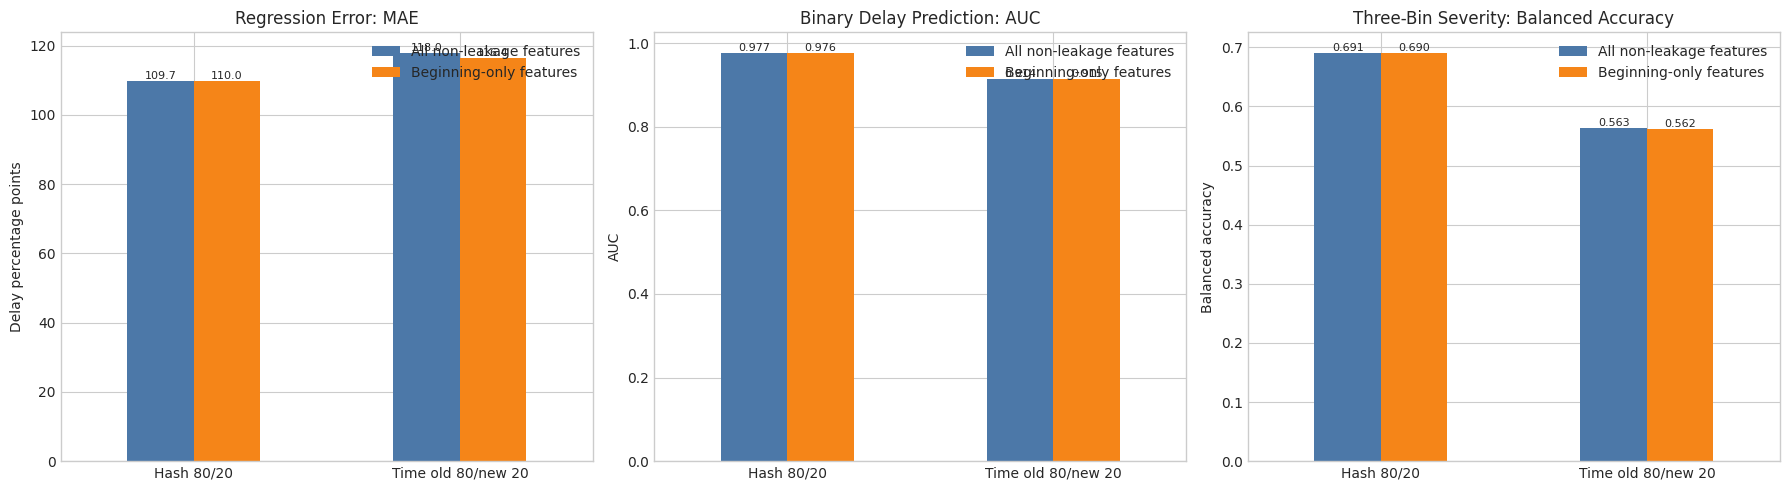

In [4]:
plot_df = headline.copy()
plot_df['Feature Set'] = plot_df['FeatureSet'].map(feature_label)
colors = {'All non-leakage features': '#4c78a8', 'Beginning-only features': '#f58518'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('Regression_MAE', 'Regression Error: MAE', 'Delay percentage points', False),
    ('Binary_AUC', 'Binary Delay Prediction: AUC', 'AUC', True),
    ('ThreeBin_BalancedAccuracy', 'Three-Bin Severity: Balanced Accuracy', 'Balanced accuracy', True),
]
for ax, (metric, title, ylabel, higher_better) in zip(axes, metrics):
    pivot = plot_df.pivot(index='Split', columns='Feature Set', values=metric)
    pivot = pivot[['All non-leakage features', 'Beginning-only features']]
    pivot.plot(kind='bar', ax=ax, color=[colors[c] for c in pivot.columns], rot=0)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f' if metric != 'Regression_MAE' else '%.1f', fontsize=8)
plt.tight_layout()
plt.show()

## What The Main Results Show

The beginning-only model is very close to the broader total-usable model. This matters because beginning-only features are the ones most suitable for real early-warning use.

The drop from random holdout to time split is also important. It shows that model performance is lower when the model must predict newer projects from older projects. That is a more realistic view of future deployment performance.

In [5]:
comparison_rows=[]
for split in headline['Split'].unique():
    total = headline[(headline.Split == split) & (headline.FeatureSet == 'total_usable')].iloc[0]
    before = headline[(headline.Split == split) & (headline.FeatureSet == 'before_only')].iloc[0]
    comparison_rows.append({
        'Validation View': split,
        'Binary AUC Difference, Beginning minus All': before.Binary_AUC - total.Binary_AUC,
        'Regression MAE Difference, Beginning minus All': before.Regression_MAE - total.Regression_MAE,
        '3-Bin Balanced Accuracy Difference, Beginning minus All': before.ThreeBin_BalancedAccuracy - total.ThreeBin_BalancedAccuracy,
    })
diff_df = pd.DataFrame(comparison_rows)
display(diff_df.style.format({
    'Binary AUC Difference, Beginning minus All': '{:+.3f}',
    'Regression MAE Difference, Beginning minus All': '{:+.1f}',
    '3-Bin Balanced Accuracy Difference, Beginning minus All': '{:+.3f}',
}))

,Validation View,"Binary AUC Difference, Beginning minus All","Regression MAE Difference, Beginning minus All","3-Bin Balanced Accuracy Difference, Beginning minus All"
0,Hash 80/20,-0.001,+0.2,-0.001
1,Time old 80/new 20,+0.000,-1.6,-0.001


## Generalization Stress Tests

The next views show harder validation tests. These are important because the client ultimately cares about whether the model will work on projects that differ by time or customer.

- **Leave-one-customer-out**: train on all customers except one, then test only on the held-out customer.
- **UDOT old-only training**: train only on the oldest 80% of UDOT projects, then test on newer UDOT and other customers. This is intentionally conservative.

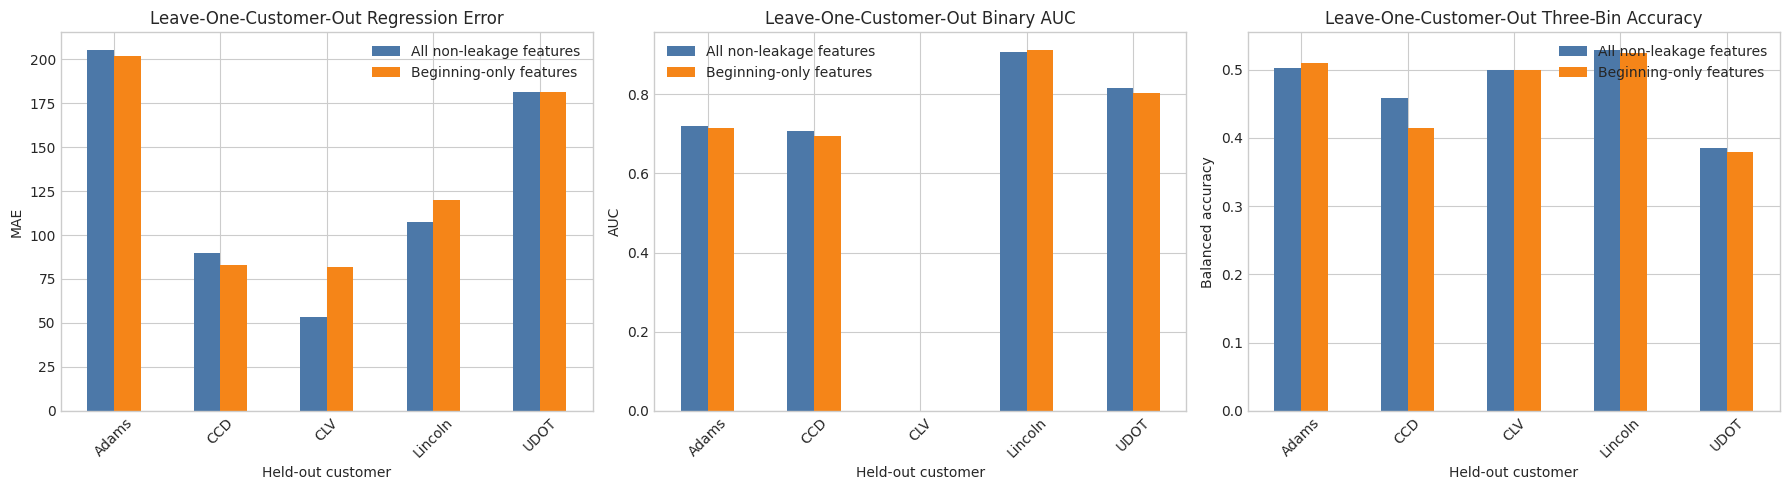

,Held-Out Customer,Feature Set,TestRows,AUC,BalancedAccuracy,Accuracy
2,Adams,Beginning-only features,77,0.716,0.664,0.740
3,Adams,All non-leakage features,77,0.719,0.627,0.714
4,CCD,Beginning-only features,192,0.694,0.639,0.672
5,CCD,All non-leakage features,192,0.707,0.651,0.672
6,CLV,Beginning-only features,2,not defined,0.500,0.500
7,CLV,All non-leakage features,2,not defined,0.500,0.500
8,Lincoln,Beginning-only features,1821,0.911,0.744,0.877
9,Lincoln,All non-leakage features,1821,0.907,0.756,0.881
10,UDOT,Beginning-only features,1377,0.803,0.630,0.948
11,UDOT,All non-leakage features,1377,0.816,0.618,0.948


Note: AUC is not defined when the held-out customer has only one observed class in the test labels. CLV has only two labeled rows, both not delayed.


In [6]:
def clean_eval_name(row):
    if pd.notna(row.get('HeldOutCustomer')) and str(row.get('HeldOutCustomer')) != 'nan':
        return str(row['HeldOutCustomer'])
    if pd.notna(row.get('EvalSet')) and str(row.get('EvalSet')) != 'nan':
        return str(row['EvalSet']).replace('_all', '')
    return row['Split']

loco_bin = binary[binary['SplitFamily'].eq('leave_one_customer_out')].copy()
loco_reg = regression[regression['SplitFamily'].eq('leave_one_customer_out')].copy()
loco_three = three_bin[three_bin['SplitFamily'].eq('leave_one_customer_out')].copy()
for d in [loco_bin, loco_reg, loco_three]:
    d['Customer'] = d.apply(clean_eval_name, axis=1)
    d['Feature Set'] = d['FeatureSet'].map(feature_label)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, d, metric, title, ylabel in [
    (axes[0], loco_reg, 'MAE', 'Leave-One-Customer-Out Regression Error', 'MAE'),
    (axes[1], loco_bin, 'AUC', 'Leave-One-Customer-Out Binary AUC', 'AUC'),
    (axes[2], loco_three, 'BalancedAccuracy', 'Leave-One-Customer-Out Three-Bin Accuracy', 'Balanced accuracy'),
]:
    pivot = d.pivot(index='Customer', columns='Feature Set', values=metric)
    pivot = pivot[[c for c in ['All non-leakage features', 'Beginning-only features'] if c in pivot.columns]]
    pivot.plot(kind='bar', ax=ax, color=[colors[c] for c in pivot.columns], rot=45)
    ax.set_title(title)
    ax.set_xlabel('Held-out customer')
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

loco_summary = binary[binary['SplitFamily'].eq('leave_one_customer_out')].copy()
loco_summary['Held-Out Customer'] = loco_summary.apply(clean_eval_name, axis=1)
loco_summary['Feature Set'] = loco_summary['FeatureSet'].map(feature_label)
loco_summary = loco_summary[['Held-Out Customer','Feature Set','TestRows','AUC','BalancedAccuracy','Accuracy']]
loco_summary['AUC'] = loco_summary['AUC'].map(lambda x: 'not defined' if pd.isna(x) else f'{x:.3f}')
loco_summary['BalancedAccuracy'] = loco_summary['BalancedAccuracy'].map(lambda x: f'{x:.3f}')
loco_summary['Accuracy'] = loco_summary['Accuracy'].map(lambda x: f'{x:.3f}')
display(loco_summary)
print('Note: AUC is not defined when the held-out customer has only one observed class in the test labels. CLV has only two labeled rows, both not delayed.')

## Conservative UDOT-Only Training Stress Test

This view is intentionally difficult. The model only gets to learn from older UDOT projects, then it is tested on newer UDOT and other customers. This is a lower-bound view of generalization from a narrow historical base.

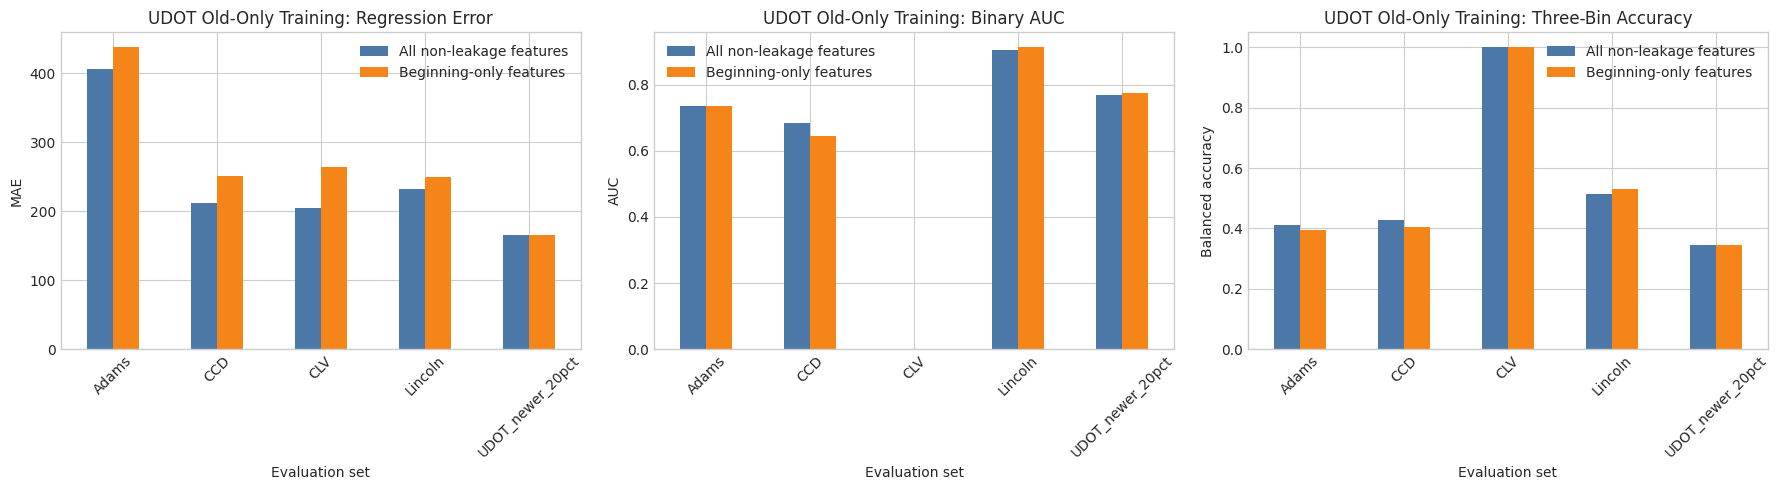

,Evaluation Set,Feature Set,TestRows,AUC,BalancedAccuracy,Accuracy
14,Adams,Beginning-only features,77,0.737,0.543,0.649
15,Adams,All non-leakage features,77,0.736,0.563,0.675
16,CCD,Beginning-only features,192,0.646,0.591,0.693
17,CCD,All non-leakage features,192,0.683,0.644,0.734
18,CLV,Beginning-only features,2,not defined,1.000,1.000
19,CLV,All non-leakage features,2,not defined,1.000,1.000
20,Lincoln,Beginning-only features,1821,0.913,0.832,0.904
21,Lincoln,All non-leakage features,1821,0.905,0.840,0.904
22,UDOT_newer_20pct,Beginning-only features,273,0.775,0.500,0.821
23,UDOT_newer_20pct,All non-leakage features,273,0.769,0.500,0.821


In [7]:
udot_bin = binary[binary['SplitFamily'].eq('udot_old_only')].copy()
udot_reg = regression[regression['SplitFamily'].eq('udot_old_only')].copy()
udot_three = three_bin[three_bin['SplitFamily'].eq('udot_old_only')].copy()
for d in [udot_bin, udot_reg, udot_three]:
    d['Evaluation Set'] = d.apply(clean_eval_name, axis=1)
    d['Feature Set'] = d['FeatureSet'].map(feature_label)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, d, metric, title, ylabel in [
    (axes[0], udot_reg, 'MAE', 'UDOT Old-Only Training: Regression Error', 'MAE'),
    (axes[1], udot_bin, 'AUC', 'UDOT Old-Only Training: Binary AUC', 'AUC'),
    (axes[2], udot_three, 'BalancedAccuracy', 'UDOT Old-Only Training: Three-Bin Accuracy', 'Balanced accuracy'),
]:
    pivot = d.pivot(index='Evaluation Set', columns='Feature Set', values=metric)
    pivot = pivot[[c for c in ['All non-leakage features', 'Beginning-only features'] if c in pivot.columns]]
    pivot.plot(kind='bar', ax=ax, color=[colors[c] for c in pivot.columns], rot=45)
    ax.set_title(title)
    ax.set_xlabel('Evaluation set')
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
plt.tight_layout()
plt.show()

udot_summary = udot_bin[['Evaluation Set','Feature Set','TestRows','AUC','BalancedAccuracy','Accuracy']].copy()
udot_summary['AUC'] = udot_summary['AUC'].map(lambda x: 'not defined' if pd.isna(x) else f'{x:.3f}')
udot_summary['BalancedAccuracy'] = udot_summary['BalancedAccuracy'].map(lambda x: f'{x:.3f}')
udot_summary['Accuracy'] = udot_summary['Accuracy'].map(lambda x: f'{x:.3f}')
display(udot_summary)

## Feature Drivers

The following charts summarize which features the random forest used most heavily in the main random holdout models. Feature importance should be interpreted as directional model reliance, not as proof of causality.

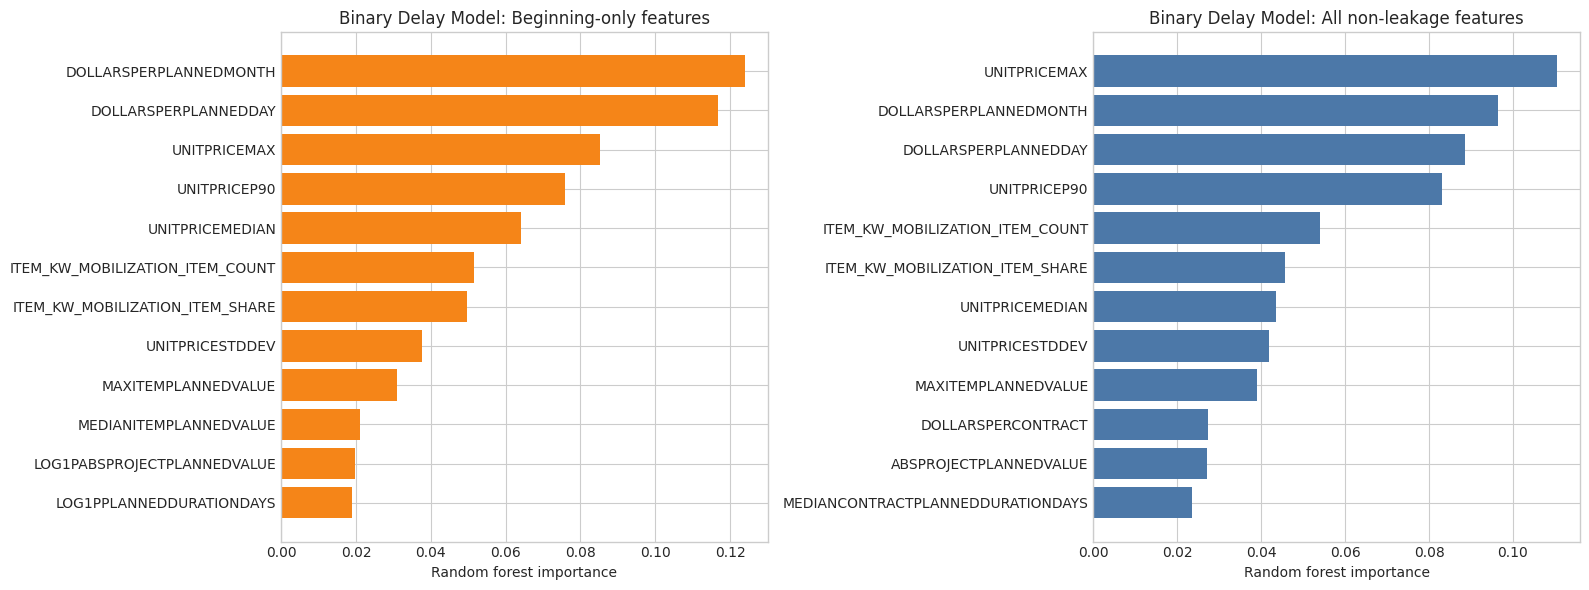

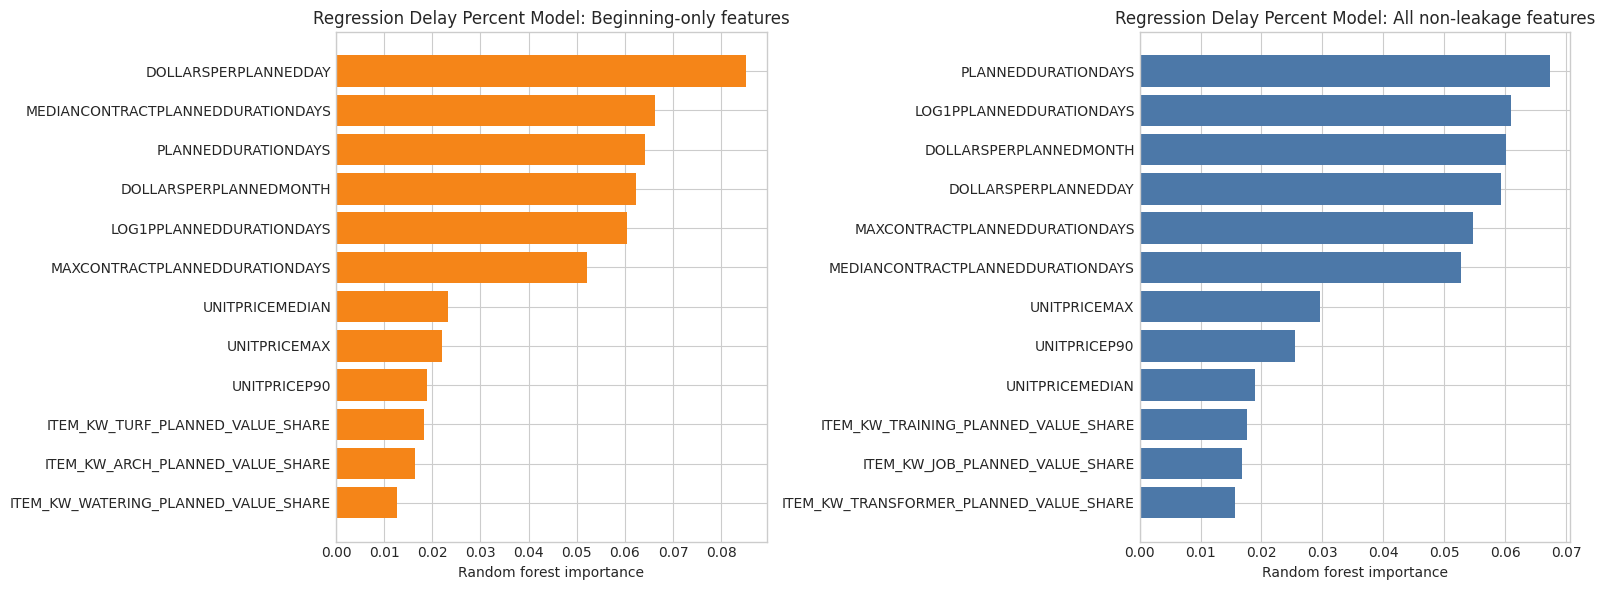

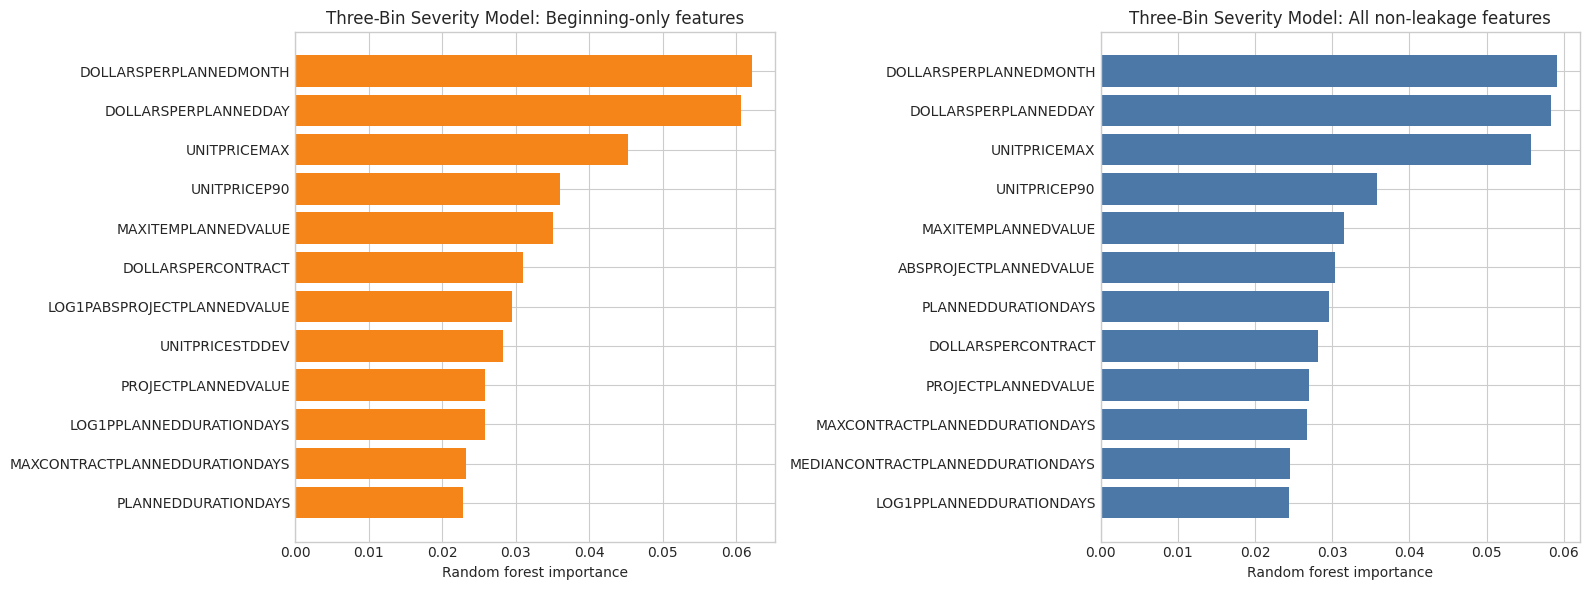

In [8]:
def load_importance(feature_set, task):
    p = Path(f'project_delay_rf_approved_keywords_{feature_set}_{task}_top_importances_2026-06-11.csv')
    d = pd.read_csv(p).head(12)
    d['Feature Set'] = feature_label[feature_set]
    d['Task'] = task
    return d

for task, title in [('binary', 'Binary Delay Model'), ('regression', 'Regression Delay Percent Model'), ('three_bin', 'Three-Bin Severity Model')]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, fs in zip(axes, ['before_only', 'total_usable']):
        imp = load_importance(fs, task).sort_values('Importance', ascending=True)
        ax.barh(imp['Feature'], imp['Importance'], color=colors[feature_label[fs]])
        ax.set_title(f'{title}: {feature_label[fs]}')
        ax.set_xlabel('Random forest importance')
    plt.tight_layout()
    plt.show()

## Practical Interpretation

The current model appears useful as a **risk-screening tool**:

- It can help identify projects that should receive earlier review.
- It can support prioritization of project controls attention.
- It can provide a consistent, data-driven risk score based on project setup information.

The model should not yet be treated as a precise schedule-delay estimator. The three-bin severity task is meaningfully harder than the binary delayed/not-delayed task, and performance weakens under time/customer stress tests.

Recommended next steps:

1. Validate the beginning-available fields with the client, especially schedule, budget linkage, planned value, and status fields.
2. Continue improving customer-transfer validation as more labeled examples become available.
3. Consider presenting the first production version as a binary or risk-score model rather than a precise severity model.
4. Track model performance by customer and over time after deployment.

## Appendix: Why Some Metrics Are Not Shown

Some metrics are only meaningful for certain model tasks:

- Regression uses error metrics like MAE and RMSE.
- Binary classification uses ROC AUC and binary classification accuracy metrics.
- Three-bin classification uses multiclass accuracy and F1 metrics.

ROC AUC is not defined when a test set contains only one observed class. This occurs for CLV in this dataset because there are only two labeled CLV projects and both are not delayed. In those cases, the notebook displays `not defined` instead of treating the result as a model failure.